In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv
import scanpy as sc

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\performance_on_simulated_data'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

In [6]:
import sys  
sys.path.insert(1,stvelo_path)
from pipelines.simulation_3ode_class import Simulation3ODE
from pipelines.metrics import *
from pipelines.preprocessing import Preprocessing
from pipelines.compute_velocity import Velocities
from pipelines.utils import proportions_nuc_cyto

In [7]:
config_simulation = {'parameters':{ 'n_obs':1200,
    'n_vars':300,
    'alpha':None,
    'beta':None,
    'nu' :None,
    'gamma':None,
    'alpha_':0,
    't_max':25,
    'noise_model':"normal",
    'noise_level':1,
    }, 

    'options': {'generate_parameters':True,
                'generate_switch_times':True,
                  'save':False,
                  'saving_path':None
                  },
    'coeff_generate_options':{ 
    'corr':[0.4, 0.3, -0.3, 0.4, -0.2, -0.1],
    'sd':[0.6, 0.6, 0.6, 0.6],
    'mean':[np.log(5), np.log(0.46), np.log(0.4), np.log(0.38)]} }


In [8]:
# Order of correlations: [rho_alpha_beta, rho_alpha_nu, rho_alpha_gamma, rho_beta_nu, rho_beta_gamma, rho_nu_gamma]
# Order of sigmas : [sigma_log_alpha, sigma_log_beta, sigma_log_nu, sigma_log_gamma]
# Order of means : [alpha,beta,nu,gamma]

# config_simulation = {'parameters':{ 'n_obs':800,
#     'n_vars':300,
#     'alpha':5,
#     'beta':0.02,
#     'nu' :0.33,
#     'gamma':0.32,
#     'alpha_':0,
#     't_max':20,
#     'noise_model':"normal",
#     'noise_level':2,
#     }, 

#     'options': {'generate_parameters':False,
#                 'generate_switch_times':True,
#                   'save':False,
#                   'saving_path':None
#                   },
#     }


config_preprocessing = {'preprocess_params': {
     'min_counts': 200, 
     'min_cells': 5,
     'n_neighbors': 15,
     'n_pcs': 0,
     'min_dist': 1},
'functions_to_apply': {'filter_cells': True, 
                       'filter_genes': True, 
                       'normalize_total': True,
                       'log1p': True,
                       'pca': True,
                       'neighbors': True,
                       'umap': True,
                       'leiden': True,
                       'moments': True}}


# config_velocity = { 'velocity_types': ['dynamical','deterministic','stochastic','velovi']}
config_velocity = { 'velocity_types': ['deterministic','stochastic','dynamical','velovi'],
                   'velovi_model_params':{'n_hidden':256,
                                    'n_latent':10,
                                    'n_layers':1,
                                    },
                    'velovi_train_params': {'epochs':600,
                                            'lr':0.01,
                                            'weight_decay':0.01,
                                            'early_stop':True,
                                            'batch_size':256}}



config_plotting = {
    'colorsets': ['leiden', 'clusters'],
    'velocity_embedding_stream': True,
    'velocity_embedding_grid': True,
    'velocity_embedding': True,
    'rank_velocity_genes': True,
    'velocity_confidence': True,
    'velocity_length': True
}



# Simulation 

In [9]:
simulator = Simulation3ODE(config= config_simulation) 
adata_dict = simulator.simulate_multi_obs_var(n_obs_list=[800,1000], n_vars_list=[300])
# adata_dict = simulator.simulation()

mean values of [alpha,beta,nu,gamma]:[1.6094379124341003, -0.7765287894989963, -0.916290731874155, -0.9675840262617056]
parameters for 300 genes,  generated with the covariance matrix: [[ 0.36   0.144  0.108 -0.108]
 [ 0.144  0.36   0.144 -0.072]
 [ 0.108  0.144  0.36  -0.036]
 [-0.108 -0.072 -0.036  0.36 ]]
6.122488121563361
0.5601620020152308
0.46987974016751605
0.4346307475905063
mean values of [alpha,beta,nu,gamma]:[1.6094379124341003, -0.7765287894989963, -0.916290731874155, -0.9675840262617056]
parameters for 300 genes,  generated with the covariance matrix: [[ 0.36   0.144  0.108 -0.108]
 [ 0.144  0.36   0.144 -0.072]
 [ 0.108  0.144  0.36  -0.036]
 [-0.108 -0.072 -0.036  0.36 ]]
5.745531801590631
0.5553315473722285
0.4568169721095021
0.47484077669110397


In [10]:
adata_dict.keys()

dict_keys(['adata_s_u_800obs_300genes', 'adata_n_c_800obs_300genes', 'adata_s_u_1000obs_300genes', 'adata_n_c_1000obs_300genes'])

In [11]:
nc_dict = {k: v.copy() for k, v in adata_dict.items() if '_n_c_' in k}

In [12]:
nc_dict

{'adata_n_c_800obs_300genes': AnnData object with n_obs × n_vars = 800 × 300
     obs: 'true_t'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity',
 'adata_n_c_1000obs_300genes': AnnData object with n_obs × n_vars = 1000 × 300
     obs: 'true_t'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity'}

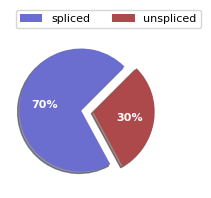

In [70]:
scv.pl.proportions(adata_dict['adata_s_u_800obs_300genes'])

<Axes: >

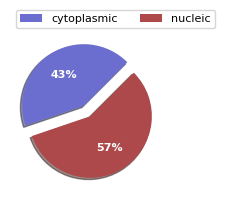

In [13]:
proportions_nuc_cyto(adata_dict['adata_n_c_800obs_300genes'])

# Preprocessing 

In [10]:
adata_800 = adata_dict['adata_n_c_800obs_300genes']
# adata_1000 = adata_dict['adata_n_c_1000obs_300genes']
# adata_2000 = adata_dict['adata_n_c_2000obs_300genes']
# adata_3000 = adata_dict['adata_n_c_3000obs_500genes']
# adata_1 = adata_dict['adata_n_c_800obs_300genes']

In [45]:
adata_800.var['true_t_'].max()

22.458788694728472

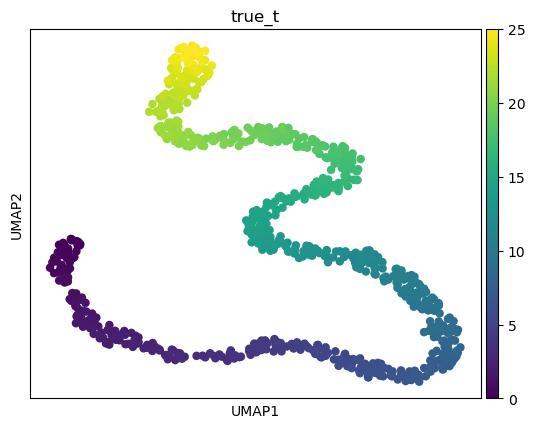

In [11]:
sc.pp.neighbors(adata_800, n_neighbors=15, n_pcs=0)

sc.tl.umap(adata_800, min_dist=1)

sc.pl.umap(adata_800,color='true_t')

In [14]:
for key, adata in nc_dict.items():
    print(f'{key} is being preprocessed.')
    preprocessor = Preprocessing(adata,config_preprocessing)
    adata = preprocessor.preprocess_data()

adata_n_c_800obs_300genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_1000obs_300genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


# Velocity 

In [15]:
velocity_computer = Velocities(nc_dict,config_velocity)
adata_dict_velocity = velocity_computer.compute_velocities()

Using device: cuda
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:22) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
recovering dynamics (using 8/24 cores)
    finished (0:00:24) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
dynamical velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for ea

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX A2000 8GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 600/600: 100%|██████████| 600/600 [00:56<00:00, 12.14it/s, v_num=1, train_loss_step=1.15e+3, train_loss_epoch=1.16e+3]

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 600/600: 100%|██████████| 600/600 [00:56<00:00, 10.71it/s, v_num=1, train_loss_step=1.15e+3, train_loss_epoch=1.16e+3]
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', s

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 355/600:  59%|█████▉    | 355/600 [01:27<01:00,  4.04it/s, v_num=1, train_loss_step=1.28e+3, train_loss_epoch=1.25e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1231.982. Signaling Trainer to stop.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [16]:
os.getcwd()

saving_path = os.path.join(os.getcwd(),'data','perf_sim_data6')
saving_path_vae = os.path.join(os.getcwd(),'data','vae')

vae = adata_dict_velocity[0]

np.save(os.path.join(saving_path_vae,'perf_sim_data5_1107'), vae) 


adata_dict = adata_dict_velocity[1]

for d in adata_dict.keys():
    print(d)
    adata_dict[d].write(os.path.join(saving_path,d+'.h5ad'))

adata_n_c_800obs_300genes_deterministic
adata_n_c_800obs_300genes_stochastic
adata_n_c_800obs_300genes_dynamical
adata_n_c_800obs_300genes_velovi
adata_n_c_1000obs_300genes_deterministic
adata_n_c_1000obs_300genes_stochastic
adata_n_c_1000obs_300genes_dynamical
adata_n_c_1000obs_300genes_velovi


# Save adatas 

In [32]:
adata_dict = adata_dict_velocity[1]

In [33]:
list(adata_dict.keys())

['adata_s_u_800obs_300genes_deterministic',
 'adata_s_u_800obs_300genes_stochastic',
 'adata_s_u_800obs_300genes_dynamical',
 'adata_s_u_800obs_300genes_velovi',
 'adata_n_c_800obs_300genes_deterministic',
 'adata_n_c_800obs_300genes_stochastic',
 'adata_n_c_800obs_300genes_dynamical',
 'adata_n_c_800obs_300genes_velovi']

In [37]:
adata = adata_dict['adata_n_c_800obs_300genes_dynamical']

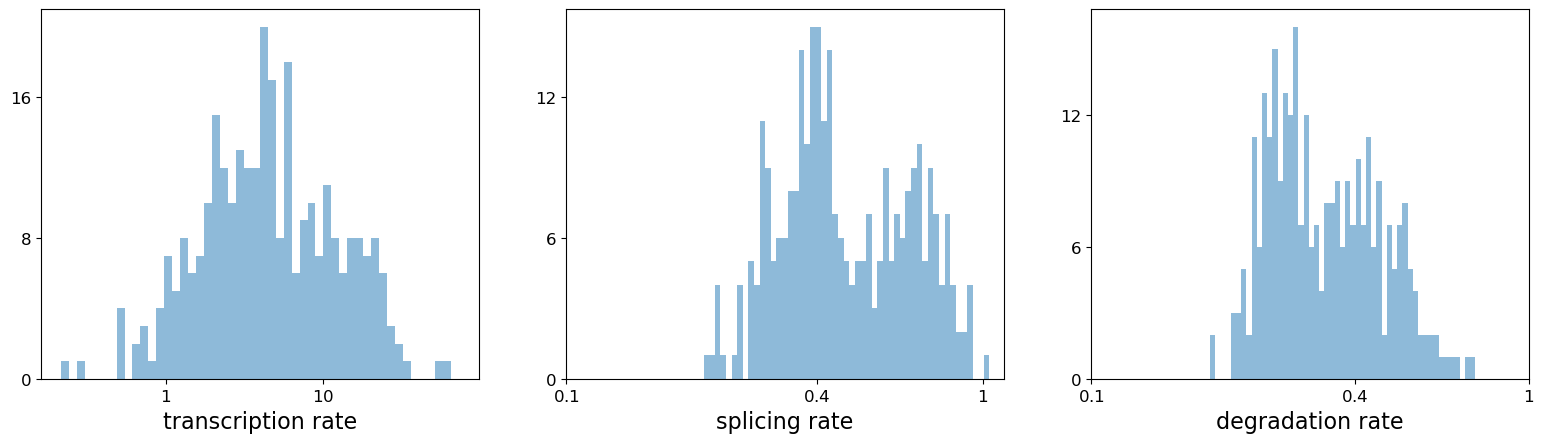

,fit_r2,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling
0,0.892735,2.052638,0.089248,0.278476,12.050723,3.918247,9.949059,2.799425,1.087378,0.0,0.0,0.468819,23.340363,6.751425,0.018099,3.002599
1,0.873900,5.756166,0.146334,0.287283,10.399569,2.779569,16.103525,6.759123,1.586131,0.0,0.0,0.480445,39.337260,16.512788,0.016510,2.868296
2,0.959663,0.983416,0.166089,0.357748,9.991368,1.942874,2.635274,1.017285,1.527187,0.0,0.0,0.378312,5.877211,2.382456,0.017328,2.324218
3,0.688019,10.633194,0.198880,0.336791,11.327074,2.592251,21.094709,10.300849,1.340231,0.0,0.0,0.494843,52.754144,25.994051,0.016796,2.338402
4,0.949538,0.949629,0.058292,0.260354,11.006954,7.209327,6.957379,1.302821,1.043172,0.0,0.0,0.452565,16.421060,3.180421,0.035865,3.212390


In [38]:
df = adata.var
# df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]
kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)

scv.get_df(adata, 'fit*', dropna=True).head()

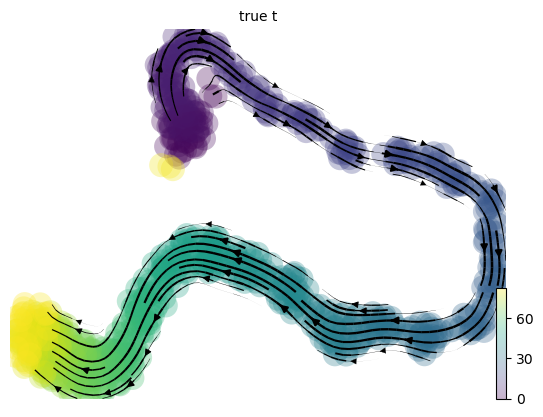

In [41]:
scv.pl.velocity_embedding_stream(adata,color='true_t')

In [ ]:
scv.datasets.simulation

In [ ]:
alpha=df['fit_alpha'].values
beta=df['fit_beta'].values
gamma=df['fit_gamma'].values
switches = df['fit_t_'].values
switches = switches[~np.isnan(switches)]
alpha = gamma[~np.isnan(gamma)]
beta = beta[~np.isnan(beta)]
gamma = gamma[~np.isnan(gamma)]

In [109]:
switches = switches/np.max(switches)

In [110]:
adata_800 = scv.datasets.simulation(n_obs=800,n_vars=299,
    alpha=alpha,
    beta=beta,
    gamma=gamma,
    switches=switches
)


In [116]:
preprocessor = Preprocessing(adata_800,config_preprocessing)
adata_800 = preprocessor.preprocess_data()

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [118]:
adata_2ode_sim_dict = {'adata_n_c_800obs_299genes': adata_800}

In [119]:
velocity_computer = Velocities(adata_2ode_sim_dict,config_velocity)
adata_dict_velocity_800 = velocity_computer.compute_velocities()

Using device: cuda
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
recovering dynamics (using 8/24 cores)
    finished (0:00:17) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
dynamical velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (u

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


    finished (0:00:18) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
min_max_scaler is working!
Epoch 600/600: 100%|██████████| 600/600 [00:34<00:00, 17.79it/s, v_num=1, train_loss_step=-433, train_loss_epoch=-430]  

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 600/600: 100%|██████████| 600/600 [00:34<00:00, 17.31it/s, v_num=1, train_loss_step=-433, train_loss_epoch=-430]
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [120]:
os.getcwd()

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github'

In [126]:
saving_path = os.path.join(os.getcwd(),'data','2d')
saving_path_vae = os.path.join(os.getcwd(),'data','vae')

In [122]:
vae = adata_dict_velocity_800[0]

In [ ]:
np.save(os.path.join(saving_path_vae,'800_1106_800_obs_2d'), vae) 


In [124]:
adata_dict_800 = adata_dict_velocity_800[1]

In [128]:
for d in adata_dict_800.keys():
    print(d)
    adata_dict_800[d].write(os.path.join(saving_path,d+'.h5ad'))

adata_n_c_800obs_299genes_deterministic
adata_n_c_800obs_299genes_stochastic
adata_n_c_800obs_299genes_dynamical
adata_n_c_800obs_299genes_velovi


In [ ]:
#-----------------------------------

In [ ]:
saving_path = os.path.join(os.getcwd(),'data','perf_sim_data4')
saving_path_vae = os.path.join(os.getcwd(),'data','vae')

In [227]:
vae = adata_dict_velocity[0]

In [228]:
np.save(os.path.join(saving_path_vae,'800_1106_800_obs'), vae) 

In [229]:
adata_dict = adata_dict_velocity[1]

In [230]:
for d in adata_dict.keys():
    print(d)
    adata_dict[d].write(os.path.join(saving_path,d+'.h5ad'))

adata_s_u_800obs_300genes_deterministic
adata_s_u_800obs_300genes_stochastic
adata_s_u_800obs_300genes_dynamical
adata_s_u_800obs_300genes_velovi
adata_n_c_800obs_300genes_deterministic
adata_n_c_800obs_300genes_stochastic
adata_n_c_800obs_300genes_dynamical
adata_n_c_800obs_300genes_velovi
